In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay
)

In [55]:
df = pd.read_csv("../data/raw/PhiUSIIL_Phishing_URL_Dataset.csv")

In [56]:
print("Shape:", df.shape)
print("Missing values total:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
print("Constant columns:", constant_cols)

print("\nLabel distribution:")
print(df["label"].value_counts())
print("\nLabel percentages:")
print(df["label"].value_counts(normalize=True) * 100)

Shape: (235795, 56)
Missing values total: 0
Duplicate rows: 0
Constant columns: []

Label distribution:
label
1    134850
0    100945
Name: count, dtype: int64

Label percentages:
label
1    57.189508
0    42.810492
Name: proportion, dtype: float64


In [57]:
text_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
print("\nText columns:", text_cols)


Text columns: ['FILENAME', 'URL', 'Domain', 'TLD', 'Title']


In [58]:
df_baseline = df.drop(columns=text_cols)

X = df_baseline.drop(columns=["label"])
y = df_baseline["label"]

print("\nX shape:", X.shape)
print("y shape:", y.shape)
print("\nFeature dtypes:")
print(X.dtypes.value_counts())


X shape: (235795, 50)
y shape: (235795,)

Feature dtypes:
int64      40
float64    10
Name: count, dtype: int64


In [59]:
df_baseline.to_csv("../data/processed/dataset_baseline_v1.csv", index=False)

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain/Test shapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


Train/Test shapes:
X_train: (188636, 50)
X_test : (47159, 50)
y_train: (188636,)
y_test : (47159,)


In [61]:
baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000, random_state=42))
])

baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('logreg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not w

In [62]:
y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]

In [63]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

print("\nBaseline Model Evaluation")
print("-" * 40)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")
print(f"PR AUC    : {pr_auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


Baseline Model Evaluation
----------------------------------------
Accuracy  : 0.9999
Precision : 0.9998
Recall    : 1.0000
F1 Score  : 0.9999
ROC AUC   : 1.0000
PR AUC    : 1.0000

Confusion Matrix:
[[20183     6]
 [    0 26970]]

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9997    0.9999     20189
           1     0.9998    1.0000    0.9999     26970

    accuracy                         0.9999     47159
   macro avg     0.9999    0.9999    0.9999     47159
weighted avg     0.9999    0.9999    0.9999     47159



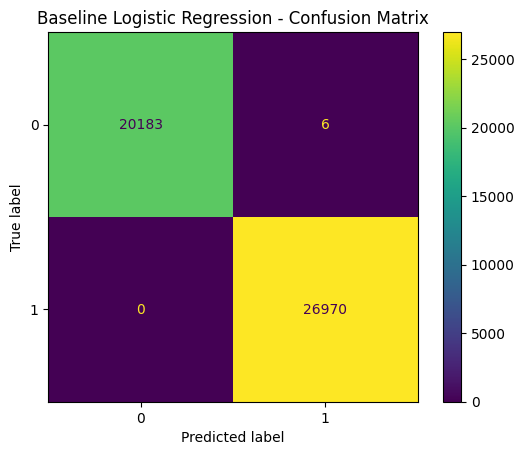

In [67]:
ConfusionMatrixDisplay.from_estimator(
    baseline_model,
    X_test,
    y_test,
    values_format="d",
    cmap="viridis"
)
plt.title("Baseline Logistic Regression - Confusion Matrix")
plt.show()

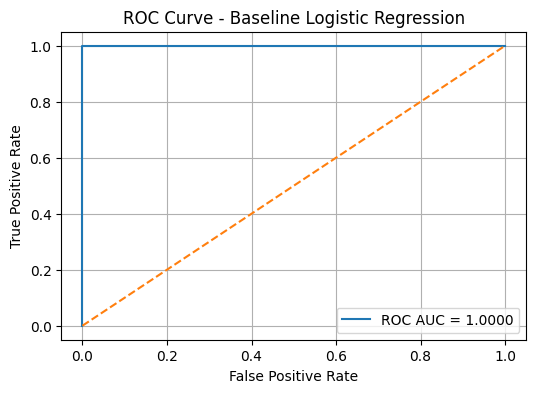

In [65]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Baseline Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

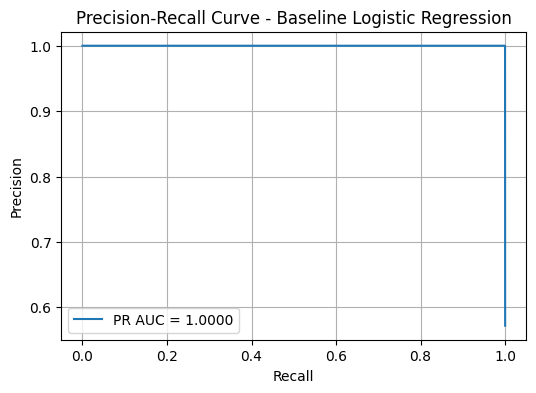

In [66]:
precisions, recalls, _ = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(recalls, precisions, label=f"PR AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Baseline Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

Baseline Conclusion
Baseline model: Logistic Regression with StandardScaler
Test accuracy is extremely high
Confusion matrix shows only 6 false positives and 0 false negatives
This result is promising, but it requires validation to check for possible leakage or overly informative features
Next step: validation and leakage check

In [68]:
# Extract feature names
feature_names = X_train.columns

# Extract trained logistic regression model from pipeline
logreg_model = baseline_model.named_steps["logreg"]

# Get coefficients
coefficients = logreg_model.coef_[0]

# Build dataframe
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "abs_coefficient": np.abs(coefficients)
})

# Sort by absolute importance
coef_df_sorted = coef_df.sort_values(by="abs_coefficient", ascending=False)

print("Top 20 Most Influential Features:")
display(coef_df_sorted.head(20))

print("\nTop 10 Features pushing toward Phishing (label=1):")
display(coef_df.sort_values(by="coefficient", ascending=False).head(10))

print("\nTop 10 Features pushing toward Legitimate (label=0):")
display(coef_df.sort_values(by="coefficient", ascending=True).head(10))

Top 20 Most Influential Features:


,feature,coefficient,abs_coefficient
3,URLSimilarityIndex,7.144740,7.144740
21,IsHTTPS,3.910232,3.910232
20,SpacialCharRatioInURL,-1.888559,1.888559
13,LetterRatioInURL,-1.750995,1.750995
47,NoOfSelfRef,1.637538,1.637538
46,NoOfJS,1.598587,1.598587
36,HasSocialNet,1.485065,1.485065
49,NoOfExternalRef,1.428235,1.428235
44,NoOfImage,1.336070,1.336070
15,DegitRatioInURL,-1.269880,1.269880



Top 10 Features pushing toward Phishing (label=1):


,feature,coefficient,abs_coefficient
3,URLSimilarityIndex,7.144740,7.144740
21,IsHTTPS,3.910232,3.910232
47,NoOfSelfRef,1.637538,1.637538
46,NoOfJS,1.598587,1.598587
36,HasSocialNet,1.485065,1.485065
49,NoOfExternalRef,1.428235,1.428235
44,NoOfImage,1.336070,1.336070
8,NoOfSubDomain,1.235244,1.235244
22,LineOfCode,1.151420,1.151420
1,DomainLength,1.129755,1.129755



Top 10 Features pushing toward Legitimate (label=0):


,feature,coefficient,abs_coefficient
20,SpacialCharRatioInURL,-1.888559,1.888559
13,LetterRatioInURL,-1.750995,1.750995
15,DegitRatioInURL,-1.269880,1.269880
23,LargestLineLength,-1.037715,1.037715
4,CharContinuationRate,-0.620203,0.620203
19,NoOfOtherSpecialCharsInURL,-0.598031,0.598031
5,TLDLegitimateProb,-0.319850,0.319850
35,HasExternalFormSubmit,-0.318177,0.318177
12,NoOfLettersInURL,-0.264347,0.264347
14,NoOfDegitsInURL,-0.216642,0.216642


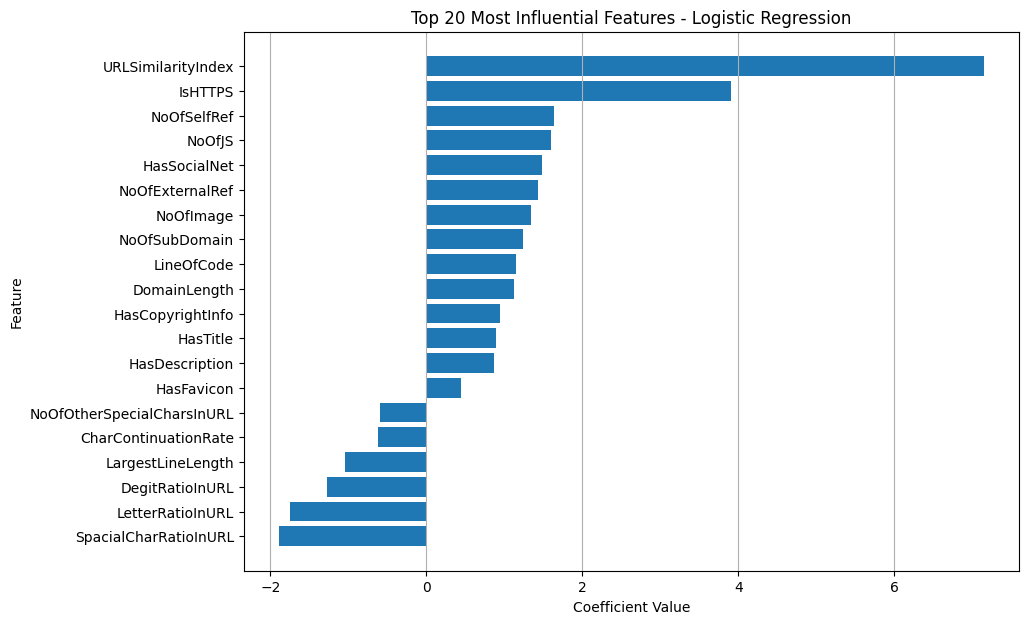

In [69]:
top_n = 20
top_features = coef_df_sorted.head(top_n).sort_values(by="coefficient")

plt.figure(figsize=(10, 7))
plt.barh(top_features["feature"], top_features["coefficient"])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Top 20 Most Influential Features - Logistic Regression")
plt.grid(True, axis="x")
plt.show()

In [70]:
df.groupby("label")["URLSimilarityIndex"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,100945.0,49.616973,22.572082,0.155574,32.120613,51.419332,67.251462,100.0
1,134850.0,100.000000,0.000000,100.000000,100.000000,100.000000,100.000000,100.0


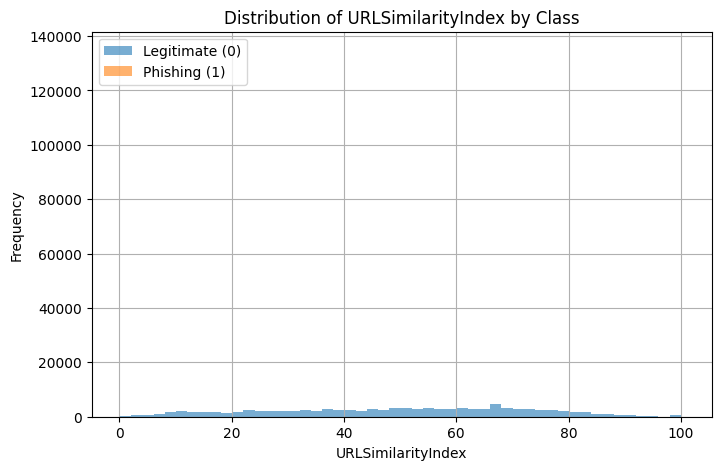

In [71]:
plt.figure(figsize=(8, 5))

df[df["label"] == 0]["URLSimilarityIndex"].plot(kind="hist", bins=50, alpha=0.6, label="Legitimate (0)")
df[df["label"] == 1]["URLSimilarityIndex"].plot(kind="hist", bins=50, alpha=0.6, label="Phishing (1)")

plt.xlabel("URLSimilarityIndex")
plt.ylabel("Frequency")
plt.title("Distribution of URLSimilarityIndex by Class")
plt.legend()
plt.grid(True)
plt.show()

<Figure size 600x400 with 0 Axes>

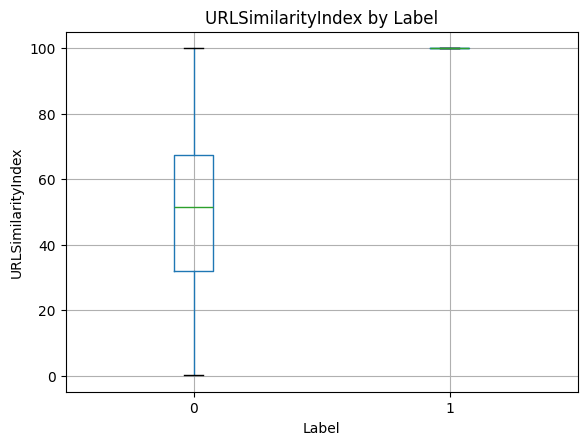

In [72]:
plt.figure(figsize=(6, 4))
df.boxplot(column="URLSimilarityIndex", by="label")
plt.title("URLSimilarityIndex by Label")
plt.suptitle("")
plt.xlabel("Label")
plt.ylabel("URLSimilarityIndex")
plt.show()

In [73]:
df_baseline_v2 = df_baseline.drop(columns=["URLSimilarityIndex"])

X_v2 = df_baseline_v2.drop(columns=["label"])
y_v2 = df_baseline_v2["label"]

print("X_v2 shape:", X_v2.shape)
print("y_v2 shape:", y_v2.shape)

X_v2 shape: (235795, 49)
y_v2 shape: (235795,)


In [74]:
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2,
    test_size=0.2,
    random_state=42,
    stratify=y_v2
)

print("X_train_v2:", X_train_v2.shape)
print("X_test_v2 :", X_test_v2.shape)
print("y_train_v2:", y_train_v2.shape)
print("y_test_v2 :", y_test_v2.shape)

X_train_v2: (188636, 49)
X_test_v2 : (47159, 49)
y_train_v2: (188636,)
y_test_v2 : (47159,)


In [75]:
baseline_model_v2 = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000, random_state=42))
])

baseline_model_v2.fit(X_train_v2, y_train_v2)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('logreg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not w

In [76]:
y_pred_v2 = baseline_model_v2.predict(X_test_v2)
y_proba_v2 = baseline_model_v2.predict_proba(X_test_v2)[:, 1]

accuracy_v2 = accuracy_score(y_test_v2, y_pred_v2)
precision_v2 = precision_score(y_test_v2, y_pred_v2)
recall_v2 = recall_score(y_test_v2, y_pred_v2)
f1_v2 = f1_score(y_test_v2, y_pred_v2)
roc_auc_v2 = roc_auc_score(y_test_v2, y_proba_v2)
pr_auc_v2 = average_precision_score(y_test_v2, y_proba_v2)
cm_v2 = confusion_matrix(y_test_v2, y_pred_v2)

print("Baseline v2 (without URLSimilarityIndex)")
print("-" * 50)
print(f"Accuracy  : {accuracy_v2:.4f}")
print(f"Precision : {precision_v2:.4f}")
print(f"Recall    : {recall_v2:.4f}")
print(f"F1 Score  : {f1_v2:.4f}")
print(f"ROC AUC   : {roc_auc_v2:.4f}")
print(f"PR AUC    : {pr_auc_v2:.4f}")

print("\nConfusion Matrix:")
print(cm_v2)

print("\nClassification Report:")
print(classification_report(y_test_v2, y_pred_v2, digits=4))

Baseline v2 (without URLSimilarityIndex)
--------------------------------------------------
Accuracy  : 0.9992
Precision : 0.9991
Recall    : 0.9994
F1 Score  : 0.9993
ROC AUC   : 1.0000
PR AUC    : 1.0000

Confusion Matrix:
[[20165    24]
 [   16 26954]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9992    0.9988    0.9990     20189
           1     0.9991    0.9994    0.9993     26970

    accuracy                         0.9992     47159
   macro avg     0.9992    0.9991    0.9991     47159
weighted avg     0.9992    0.9992    0.9992     47159



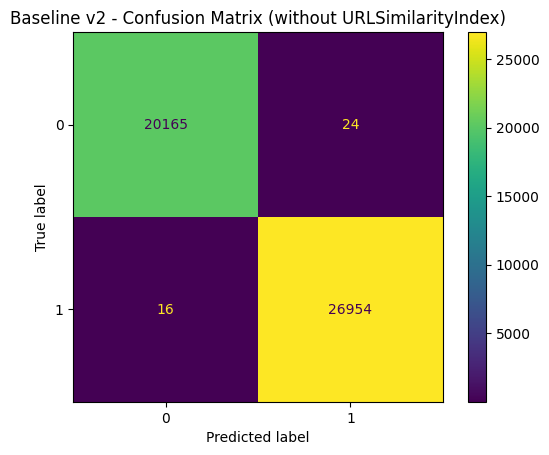

In [77]:
ConfusionMatrixDisplay.from_estimator(
    baseline_model_v2,
    X_test_v2,
    y_test_v2,
    values_format="d",
    cmap="viridis"
)
plt.title("Baseline v2 - Confusion Matrix (without URLSimilarityIndex)")
plt.show()

In [78]:
url_features = [
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "TLDLegitimateProb",
    "URLCharProb",
    "TLDLength",
    "NoOfSubDomain",
    "HasObfuscation",
    "NoOfObfuscatedChar",
    "ObfuscationRatio",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
    "IsHTTPS",
    "DomainTitleMatchScore",
    "URLTitleMatchScore",
    "CharContinuationRate"
]

page_content_features = [
    "LineOfCode",
    "LargestLineLength",
    "HasTitle",
    "HasFavicon",
    "Robots",
    "IsResponsive",
    "NoOfURLRedirect",
    "NoOfSelfRedirect",
    "HasDescription",
    "NoOfPopup",
    "NoOfiFrame",
    "HasExternalFormSubmit",
    "HasSocialNet",
    "HasSubmitButton",
    "HasHiddenFields",
    "HasPasswordField",
    "Bank",
    "Pay",
    "Crypto",
    "HasCopyrightInfo",
    "NoOfImage",
    "NoOfCSS",
    "NoOfJS",
    "NoOfSelfRef",
    "NoOfEmptyRef",
    "NoOfExternalRef"
]

remaining_features = sorted(set(X_v2.columns) - set(url_features) - set(page_content_features))

print("URL-based features:", len(url_features))
print("Page/content-based features:", len(page_content_features))
print("Remaining/unclassified features:", remaining_features)

URL-based features: 23
Page/content-based features: 26
Remaining/unclassified features: []


In [79]:
X_url_only = df_baseline_v2[url_features]
y_url_only = df_baseline_v2["label"]

X_train_url, X_test_url, y_train_url, y_test_url = train_test_split(
    X_url_only, y_url_only,
    test_size=0.2,
    random_state=42,
    stratify=y_url_only
)

url_only_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000, random_state=42))
])

url_only_model.fit(X_train_url, y_train_url)

y_pred_url = url_only_model.predict(X_test_url)
y_proba_url = url_only_model.predict_proba(X_test_url)[:, 1]

print("URL-only Logistic Regression")
print("-" * 40)
print(f"Accuracy  : {accuracy_score(y_test_url, y_pred_url):.4f}")
print(f"Precision : {precision_score(y_test_url, y_pred_url):.4f}")
print(f"Recall    : {recall_score(y_test_url, y_pred_url):.4f}")
print(f"F1 Score  : {f1_score(y_test_url, y_pred_url):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test_url, y_proba_url):.4f}")
print(f"PR AUC    : {average_precision_score(y_test_url, y_proba_url):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_url, y_pred_url))

print("\nClassification Report:")
print(classification_report(y_test_url, y_pred_url, digits=4))

URL-only Logistic Regression
----------------------------------------
Accuracy  : 0.9961
Precision : 0.9938
Recall    : 0.9995
F1 Score  : 0.9966
ROC AUC   : 0.9990
PR AUC    : 0.9988

Confusion Matrix:
[[20021   168]
 [   14 26956]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9993    0.9917    0.9955     20189
           1     0.9938    0.9995    0.9966     26970

    accuracy                         0.9961     47159
   macro avg     0.9966    0.9956    0.9961     47159
weighted avg     0.9962    0.9961    0.9961     47159



Validation Conclusion:
- URLSimilarityIndex was found to be suspiciously predictive and was removed from further trusted baselines.
- A second baseline without URLSimilarityIndex still achieved very high performance.
- A URL-only logistic regression model also performed extremely well.
- Based on this validation, the project will proceed primarily with a URL-only modeling direction because it aligns better with the intended product design and deployment workflow.

In [80]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, random_state=42))
    ]),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=200,
        random_state=42
    )
}

print(models.keys())

dict_keys(['Logistic Regression', 'Random Forest', 'HistGradientBoosting'])


In [81]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
    
    results = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba),
        "PR AUC": average_precision_score(y_test, y_proba)
    }
    
    return results

In [84]:
benchmark_results = []

for model_name, model in models.items():
    results = evaluate_model(model, X_train_url, X_test_url, y_train_url, y_test_url)
    results["Model"] = model_name
    benchmark_results.append(results)

benchmark_df = pd.DataFrame(benchmark_results)
benchmark_df = benchmark_df[["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC", "PR AUC"]]
benchmark_df = benchmark_df.sort_values(by="F1 Score", ascending=False)

benchmark_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
2,HistGradientBoosting,0.997498,0.995827,0.999815,0.997817,0.999524,0.999538
1,Random Forest,0.996904,0.995859,0.998739,0.997297,0.999167,0.998801
0,Logistic Regression,0.996141,0.993806,0.999481,0.996635,0.999001,0.998779


In [85]:
from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, random_state=42))
    ]),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=200,
        random_state=42
    )
}

cv_results = []

for model_name, model in cv_models.items():
    scores = cross_validate(
        model,
        X_url_only,
        y_url_only,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    
    cv_results.append({
        "Model": model_name,
        "CV Accuracy Mean": scores["test_accuracy"].mean(),
        "CV Accuracy Std": scores["test_accuracy"].std(),
        "CV Precision Mean": scores["test_precision"].mean(),
        "CV Recall Mean": scores["test_recall"].mean(),
        "CV F1 Mean": scores["test_f1"].mean(),
        "CV ROC AUC Mean": scores["test_roc_auc"].mean()
    })

cv_df = pd.DataFrame(cv_results)
cv_df

,Model,CV Accuracy Mean,CV Accuracy Std,CV Precision Mean,CV Recall Mean,CV F1 Mean,CV ROC AUC Mean
0,Logistic Regression,0.996170,0.000169,0.993872,0.999466,0.996661,0.998932
1,HistGradientBoosting,0.997549,0.000123,0.996179,0.999548,0.997860,0.999390


In [86]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "learning_rate": [0.05, 0.1],
    "max_iter": [100, 200, 300],
    "max_depth": [3, 5, None]
}

hgb_model = HistGradientBoostingClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=hgb_model,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_url_only, y_url_only)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV F1 Score:")
print(grid_search.best_score_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'max_iter': 300}

Best CV F1 Score:
0.9979492992049739


In [87]:
best_hgb_model = grid_search.best_estimator_

best_hgb_model.fit(X_train_url, y_train_url)

y_pred_best = best_hgb_model.predict(X_test_url)
y_proba_best = best_hgb_model.predict_proba(X_test_url)[:, 1]

best_accuracy = accuracy_score(y_test_url, y_pred_best)
best_precision = precision_score(y_test_url, y_pred_best)
best_recall = recall_score(y_test_url, y_pred_best)
best_f1 = f1_score(y_test_url, y_pred_best)
best_roc_auc = roc_auc_score(y_test_url, y_proba_best)
best_pr_auc = average_precision_score(y_test_url, y_proba_best)
best_cm = confusion_matrix(y_test_url, y_pred_best)

print("Tuned HistGradientBoosting - Test Set Evaluation")
print("-" * 55)
print(f"Accuracy  : {best_accuracy:.4f}")
print(f"Precision : {best_precision:.4f}")
print(f"Recall    : {best_recall:.4f}")
print(f"F1 Score  : {best_f1:.4f}")
print(f"ROC AUC   : {best_roc_auc:.4f}")
print(f"PR AUC    : {best_pr_auc:.4f}")

print("\nConfusion Matrix:")
print(best_cm)

print("\nClassification Report:")
print(classification_report(y_test_url, y_pred_best, digits=4))

Tuned HistGradientBoosting - Test Set Evaluation
-------------------------------------------------------
Accuracy  : 0.9976
Precision : 0.9960
Recall    : 0.9998
F1 Score  : 0.9979
ROC AUC   : 0.9995
PR AUC    : 0.9995

Confusion Matrix:
[[20080   109]
 [    5 26965]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9946    0.9972     20189
           1     0.9960    0.9998    0.9979     26970

    accuracy                         0.9976     47159
   macro avg     0.9979    0.9972    0.9975     47159
weighted avg     0.9976    0.9976    0.9976     47159



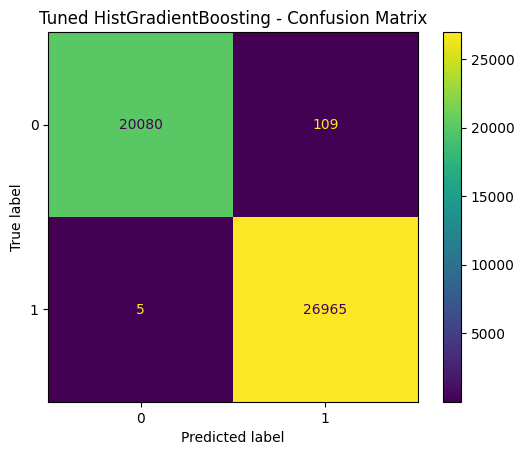

In [88]:
ConfusionMatrixDisplay.from_estimator(
    best_hgb_model,
    X_test_url,
    y_test_url,
    values_format="d",
    cmap="viridis"
)
plt.title("Tuned HistGradientBoosting - Confusion Matrix")
plt.show()

In [ ]:
import joblib
import os

os.makedirs("../src/model/artifacts", exist_ok=True)

joblib.dump(best_hgb_model, "../src/model/artifacts/phishing_url_model.pkl")
joblib.dump(url_features, "../src/model/artifacts/url_features.pkl")

print("Model and feature list saved successfully.")